# Analyse et préparation des données — Prédiction du Churn Client

Ce notebook constitue le premier livrable du projet : il analyse la qualité du dataset
*Telco Customer Churn* (Kaggle), le nettoie, et le prépare pour l'entraînement de modèles
de Machine Learning. Le jeu de données comprend 7 043 clients et 21 variables (services
souscrits, informations de compte, données démographiques).

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

I/ Analyse & Nettoyage des données

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)

# Aperçu des 5 premières lignes pour visualiser la structure des données
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Analyse de la qualité des données

`df.info()` ne signale aucune valeur manquante, mais `TotalCharges` est typée en texte
alors qu'elle devrait être numérique — signe probable de valeurs manquantes déguisées.
On convertit et on vérifie.

In [3]:
# Informations générales : types de données, nombre de valeurs non nulles par colonne
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Statistiques descriptives sur toutes les colonnes (numériques ET catégorielles grâce à include="all")
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Résultat** : 11 valeurs manquantes détectées après conversion, toutes correspondant à
des clients avec `tenure = 0` (nouveaux clients pas encore facturés). Ce n'est pas une
vraie donnée manquante mais une absence de facturation logique — traité en remplaçant
par 0 dans l'étape de nettoyage suivante. Par ailleurs, 0 doublon détecté (ni sur les
lignes, ni sur `customerID`).

In [5]:
# TotalCharges est actuellement du texte (str) alors que c'est censé être un montant numérique.
# On tente une conversion en float : les valeurs qui ne sont pas convertibles (ex: chaînes vides " ")
# seront transformées en NaN grâce à errors="coerce", ce qui les rend visibles.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Combien de valeurs sont devenues NaN après la conversion ? -> valeurs manquantes "cachées"
nb_missing_total_charges = df["TotalCharges"].isna().sum()
print(f"Valeurs manquantes détectées dans TotalCharges après conversion : {nb_missing_total_charges}")

# On affiche les lignes concernées pour comprendre pourquoi (souvent des clients avec tenure = 0,
# c'est-à-dire des nouveaux clients qui n'ont pas encore de facturation totale)
df[df["TotalCharges"].isna()][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

Valeurs manquantes détectées dans TotalCharges après conversion : 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [6]:
# Vérification des doublons : chaque client (customerID) doit apparaître une seule fois
nb_doublons = df.duplicated().sum()
nb_customerid_dupliques = df["customerID"].duplicated().sum()
print(f"Lignes entièrement dupliquées : {nb_doublons}")
print(f"customerID dupliqués : {nb_customerid_dupliques}")

Lignes entièrement dupliquées : 0
customerID dupliqués : 0


In [7]:
# Répartition de la variable cible (Churn) : indispensable pour savoir si le dataset est déséquilibré
# (un fort déséquilibre entre "Yes" et "No" impactera le choix des métriques d'évaluation plus tard)
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## 3. Nettoyage des données

Trois actions justifiées :
- `TotalCharges` : conversion en numérique + remplissage par 0 pour les 11 cas identifiés
- `customerID` : retiré, identifiant unique sans valeur prédictive (risque d'apprentissage
  par cœur si conservé)
- `Churn` : encodé en 0/1 pour être exploitable par les modèles et les métriques

In [8]:
# --- Nettoyage minimal, justifié pour le rapport de qualité de données ---

# 1) TotalCharges manquant uniquement pour les clients avec tenure=0 (nouveaux clients,
#    pas encore facturés) : on remplace logiquement par 0, ce n'est pas une vraie valeur manquante
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# 2) customerID est un identifiant unique sans valeur prédictive : le garder risquerait
#    de faire "apprendre par cœur" des identifiants au modèle -> on le retire
df = df.drop(columns=["customerID"])

# 3) Encodage de la cible : Yes/No -> 1/0, plus pratique pour scikit-learn et les métriques
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print(df.shape)
print(df["Churn"].mean().round(3))  # doit retomber sur ~0.265

(7043, 20)
0.265


## 4. Séparation train / test

Le split est effectué **une seule fois, dès maintenant**, avant toute exploration plus
poussée, afin que le jeu de test ne puisse influencer aucune décision ultérieure (choix
de modèle, hyperparamètres). Split stratifié 80/20 pour conserver la proportion de
churners (26,5 %) dans les deux jeux.

In [9]:
# --- Split train/test : UNE SEULE FOIS, dès maintenant, et on n'y touche plus ---
# Le jeu de test est un "coffre-fort" : on ne l'utilisera qu'une seule fois, à la toute fin,
# pour mesurer la performance réelle du modèle final. Toutes les décisions intermédiaires
# (exploration, choix de modèle, hyperparamètres) se prennent uniquement sur le train.
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42  # reproductibilité : on fixe la graine une fois pour toutes

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,              # conserve la proportion de churners dans train et test
    random_state=RANDOM_STATE,
)

print(f"Train : {X_train.shape[0]} clients, {y_train.mean():.3f} de churn")
print(f"Test  : {X_test.shape[0]} clients, {y_test.mean():.3f} de churn")

Train : 5634 clients, 0.265 de churn
Test  : 1409 clients, 0.265 de churn


**Synthèse de l'EDA** : les variables les plus discriminantes sont `tenure` (les
churners partent nettement plus tôt : médiane ~10 mois contre ~38), `Contract`
(43 % de churn en mensuel contre 3 % en engagement 2 ans), `InternetService`
(fibre optique : 42 % de churn contre 7 % sans internet), `PaymentMethod`
(prélèvement électronique : 46 % de churn contre 15-19 % pour les autres modes),
ainsi que l'absence de services `OnlineSecurity`/`TechSupport`. On note une forte
corrélation entre `tenure` et `TotalCharges` (0,83), redondance partielle attendue
(`TotalCharges` ≈ `tenure` × `MonthlyCharges`) mais non bloquante pour la suite —
les modèles retenus (régularisés ou à base d'arbres) gèrent bien la colinéarité.
On conserve l'ensemble des variables plutôt qu'un filtrage manuel agressif.

II/ Visualisation des données : distribution des variables numériques et catégorielles, corrélations, etc.

In [10]:
# --- Palette cohérente pour toutes les visualisations du notebook ---
# Bleu = clients qui restent, Orange = clients qui churnent (toujours les mêmes couleurs)
COULEUR_RESTE = "#2a78d6"
COULEUR_CHURN = "#eb6834"
PALETTE_CHURN = {0: COULEUR_RESTE, 1: COULEUR_CHURN}

# On reconstitue un DataFrame de travail pour l'EDA (train uniquement)
train_df = X_train.copy()
train_df["Churn"] = y_train

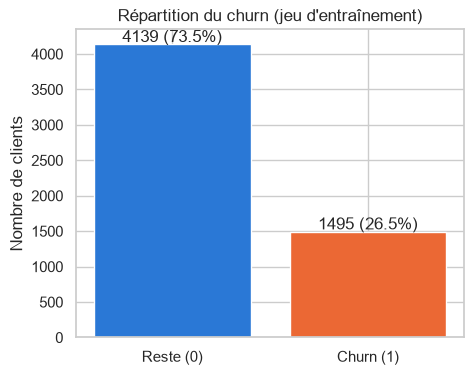

In [11]:
# --- 1. Répartition de la cible (rappel visuel du déséquilibre) ---
fig, ax = plt.subplots(figsize=(5, 4))
counts = train_df["Churn"].value_counts().sort_index()
ax.bar(["Reste (0)", "Churn (1)"], counts.values, color=[COULEUR_RESTE, COULEUR_CHURN])
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f"{v} ({v/len(train_df):.1%})", ha="center")
ax.set_title("Répartition du churn (jeu d'entraînement)")
ax.set_ylabel("Nombre de clients")
plt.show()

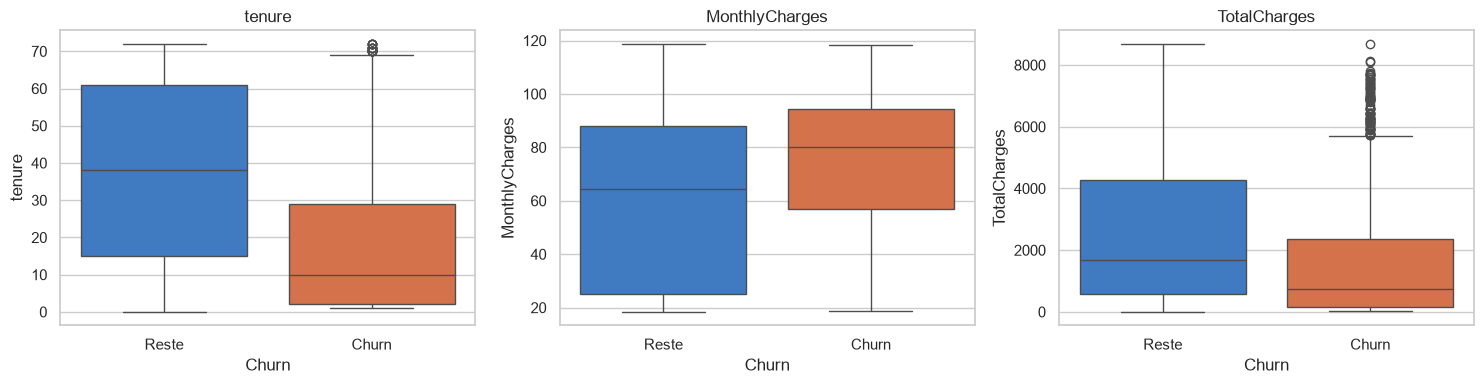

In [12]:
# --- 2. Variables numériques clés : tenure, MonthlyCharges, TotalCharges, par churn ---
num_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_vars):
    sns.boxplot(
        data=train_df, x="Churn", y=col, ax=ax,
        palette=PALETTE_CHURN, hue="Churn", legend=False,
    )
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Reste", "Churn"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

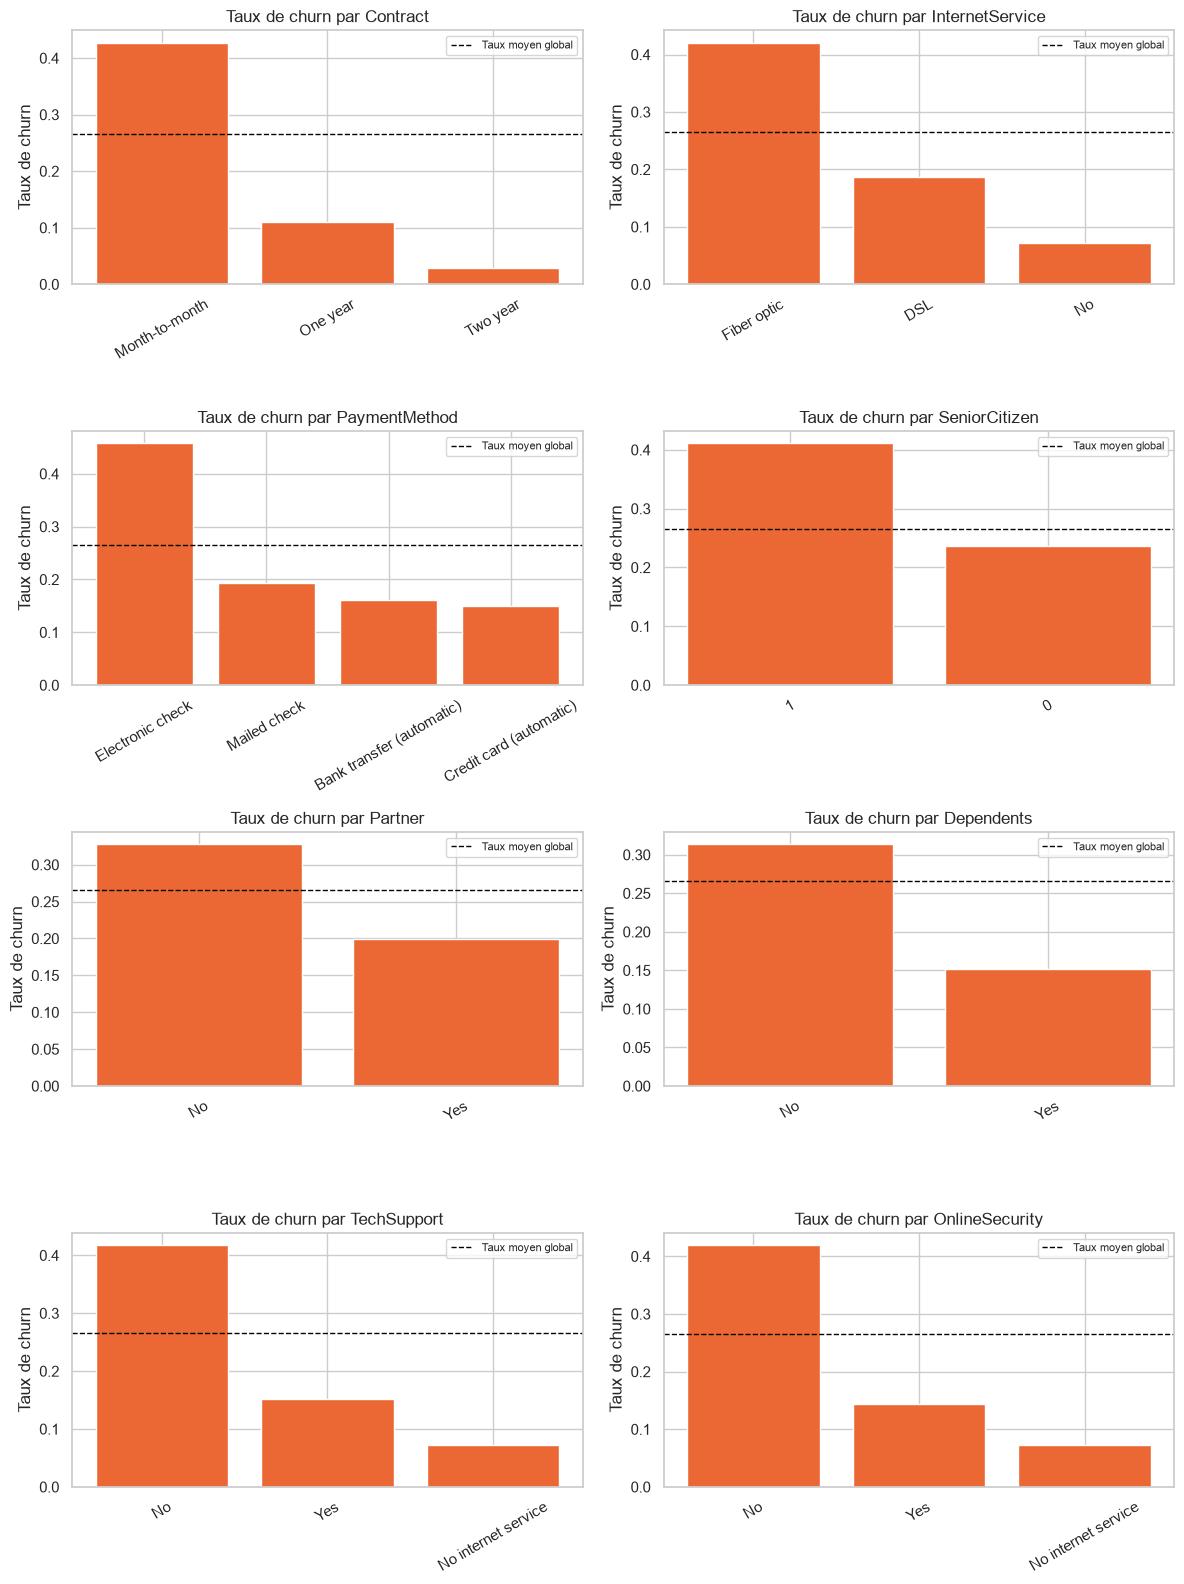

In [13]:
# --- 3. Variables catégorielles clés vs taux de churn ---
# On regarde le TAUX de churn (proportion) plutôt que les comptes bruts,
# pour comparer des catégories qui n'ont pas le même effectif
cat_vars = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen",
            "Partner", "Dependents", "TechSupport", "OnlineSecurity"]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for ax, col in zip(axes.flatten(), cat_vars):
    taux = train_df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    ax.bar(taux.index.astype(str), taux.values, color=COULEUR_CHURN)
    ax.axhline(train_df["Churn"].mean(), color="black", linestyle="--", linewidth=1,
               label="Taux moyen global")
    ax.set_title(f"Taux de churn par {col}")
    ax.set_ylabel("Taux de churn")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

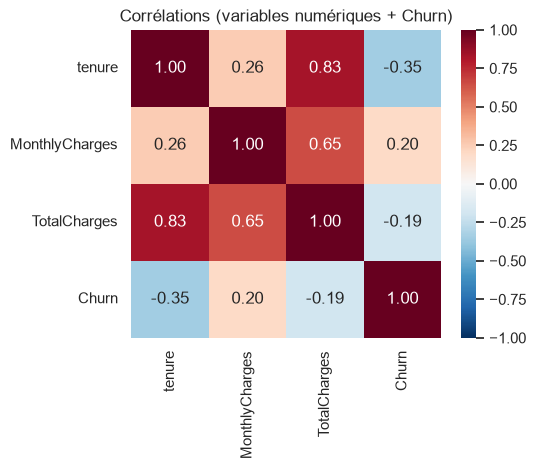

In [14]:
# --- 4. Corrélations entre variables numériques ---
# Palette divergente (bleu <-> rouge) car une corrélation a un signe (positif/négatif)
corr = train_df[num_vars + ["Churn"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Corrélations (variables numériques + Churn)")
plt.show()

## 6. Sauvegarde des données préparées

Le train et le test nettoyés sont sauvegardés dans `data/processed/` pour être repris
indépendamment dans le notebook de modélisation.

In [15]:
# --- Sauvegarde du train/test pour le notebook de modélisation ---
# On garde X et y ensemble dans chaque fichier pour simplifier le stockage
train_df_final = X_train.copy()
train_df_final["Churn"] = y_train

test_df_final = X_test.copy()
test_df_final["Churn"] = y_test

train_df_final.to_csv("../data/processed/train.csv", index=False)
test_df_final.to_csv("../data/processed/test.csv", index=False)

print("Fichiers sauvegardés dans data/processed/")

Fichiers sauvegardés dans data/processed/
